In [2]:
pip install pandas numpy matplotlib


     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     --------------------------------- ---- 71.7/80.3 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 319.7 kB/s eta 0:00:00
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ------------------------------ --------- 92.2/121.0 kB ? eta -:--:--
     ------------------------------ --------- 92.2/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 1.1 MB/s eta 0:00:01
     ------------------------------------ 12

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "../data/razorguard_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully.
Shape: (10000, 20)


In [4]:
df.head()

,order_id,customer_id,timestamp,split,return_rate_90d,category_return_rate,is_cod,order_value,discount_pct,delivery_distance_km,previous_returns,customer_age_days,previous_orders,product_rating,orders_last_30d,region_code,browser_family,device_age_days,session_hour,returned
0,4467,1365,2026-01-01 00:17:42,train,0.18,0.166667,False,5517.85,0.1232,72.5,0,88,0,3.80,0,north,edge,152,20,1
1,7312,1032,2026-01-01 00:38:04,train,0.18,0.166667,False,1695.18,0.0575,280.4,0,372,0,4.49,0,central,firefox,461,7,0
2,748,397,2026-01-01 00:43:42,train,0.18,0.166667,False,2903.76,0.0471,460.8,0,467,0,3.22,0,east,chrome,139,0,0
3,1459,54,2026-01-01 01:09:13,train,0.18,0.166667,False,1345.88,0.1349,209.2,0,154,0,3.11,0,west,in_app_webview,137,20,0
4,6293,961,2026-01-01 03:13:54,train,0.18,0.210526,True,973.10,0.0878,197.9,0,386,0,4.49,0,south,edge,1238,5,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              10000 non-null  int64  
 1   customer_id           10000 non-null  int64  
 2   timestamp             10000 non-null  str    
 3   split                 10000 non-null  str    
 4   return_rate_90d       10000 non-null  float64
 5   category_return_rate  10000 non-null  float64
 6   is_cod                10000 non-null  bool   
 7   order_value           10000 non-null  float64
 8   discount_pct          10000 non-null  float64
 9   delivery_distance_km  10000 non-null  float64
 10  previous_returns      10000 non-null  int64  
 11  customer_age_days     10000 non-null  int64  
 12  previous_orders       10000 non-null  int64  
 13  product_rating        10000 non-null  float64
 14  orders_last_30d       10000 non-null  int64  
 15  region_code           10000 non

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
customer_id,10000.0,NaN,NaN,NaN,741.4724,430.552969,1.0,371.0,739.0,1112.25,1500.0
timestamp,10000,9998,2026-01-25 14:14:02,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,10000,3,train,4929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return_rate_90d,10000.0,NaN,NaN,NaN,0.179724,0.268401,0.0,0.0,0.0,0.222222,1.0
category_return_rate,10000.0,NaN,NaN,NaN,0.177508,0.089132,0.061224,0.109442,0.159726,0.192588,0.398515
is_cod,10000,2,False,6516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_value,10000.0,NaN,NaN,NaN,5826.398219,11413.78899,157.12,1045.51,1938.42,3927.6625,104610.53
discount_pct,10000.0,NaN,NaN,NaN,0.124824,0.07213,0.0003,0.0688,0.11475,0.169525,0.4275
delivery_distance_km,10000.0,NaN,NaN,NaN,238.91665,120.486218,15.1,150.675,219.0,306.4,1030.8


In [7]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing = missing.sort_values("missing_count", ascending=False)

missing

,missing_count,missing_pct
order_id,0,0.0
customer_id,0,0.0
timestamp,0,0.0
split,0,0.0
return_rate_90d,0,0.0
category_return_rate,0,0.0
is_cod,0,0.0
order_value,0,0.0
discount_pct,0,0.0
delivery_distance_km,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

if "order_id" in df.columns:
    print("Duplicate order IDs:", df["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate order IDs: 0


In [9]:
target_col = "returned"

print("Target distribution:")
print(df[target_col].value_counts())

print("\nTarget proportions:")
print(df[target_col].value_counts(normalize=True))

Target distribution:
returned
0    8195
1    1805
Name: count, dtype: int64

Target proportions:
returned
0    0.8195
1    0.1805
Name: proportion, dtype: float64


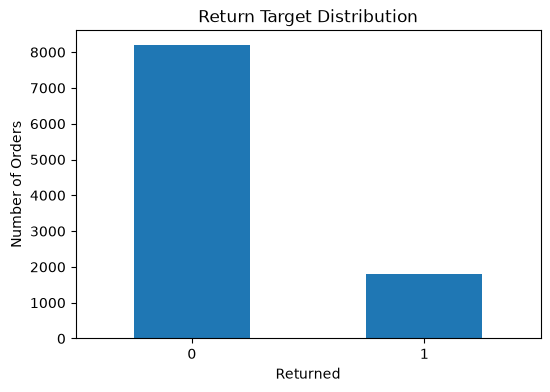

In [10]:
df[target_col].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Return Target Distribution")
plt.xlabel("Returned")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [11]:
df.columns.tolist()

['order_id',
 'customer_id',
 'timestamp',
 'split',
 'return_rate_90d',
 'category_return_rate',
 'is_cod',
 'order_value',
 'discount_pct',
 'delivery_distance_km',
 'previous_returns',
 'customer_age_days',
 'previous_orders',
 'product_rating',
 'orders_last_30d',
 'region_code',
 'browser_family',
 'device_age_days',
 'session_hour',
 'returned']

In [12]:
TIMESTAMP_COL = "timestamp"   # change if your actual column has a different name

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])

print("Minimum timestamp:", df[TIMESTAMP_COL].min())
print("Maximum timestamp:", df[TIMESTAMP_COL].max())

Minimum timestamp: 2026-01-01 00:17:42
Maximum timestamp: 2026-08-31 23:55:26


In [13]:
monthly_orders = (
    df.set_index(TIMESTAMP_COL)
      .resample("ME")
      .size()
)

monthly_orders

timestamp
2026-01-31     900
2026-02-28     818
2026-03-31     962
2026-04-30     984
2026-05-31    1265
2026-06-30    1294
2026-07-31    1576
2026-08-31    2201
Freq: ME, dtype: int64

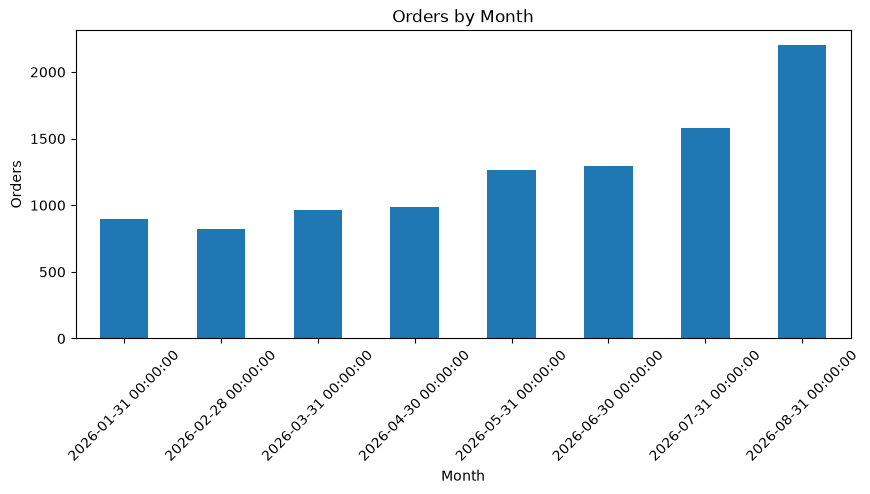

In [14]:
monthly_orders.plot(
    kind="bar",
    figsize=(10, 4)
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [15]:
monthly_return_rate = (
    df.set_index(TIMESTAMP_COL)[target_col]
      .resample("ME")
      .mean()
)

monthly_return_rate

timestamp
2026-01-31    0.163333
2026-02-28    0.185819
2026-03-31    0.185031
2026-04-30    0.185976
2026-05-31    0.177075
2026-06-30    0.170015
2026-07-31    0.180203
2026-08-31    0.189459
Freq: ME, Name: returned, dtype: float64

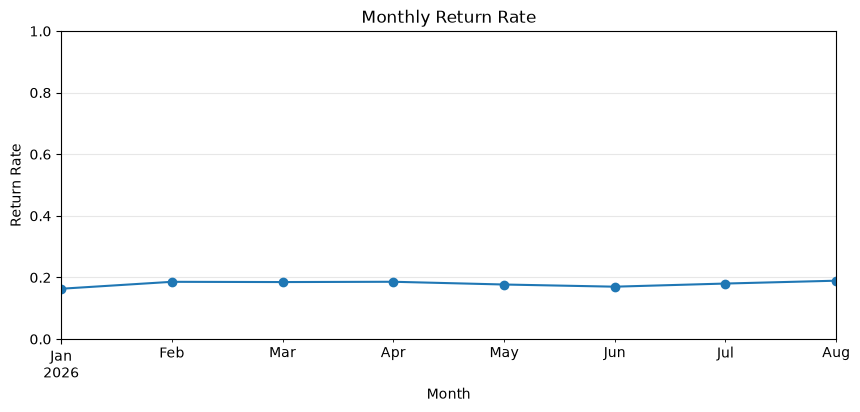

In [16]:
monthly_return_rate.plot(
    marker="o",
    figsize=(10, 4)
)

plt.title("Monthly Return Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
print(df.groupby("split")[TIMESTAMP_COL].agg(["min", "max", "count"]))

                           min                 max  count
split                                                    
test       2026-07-01 01:18:41 2026-08-31 23:55:26   3777
train      2026-01-01 00:17:42 2026-05-31 23:50:17   4929
validation 2026-06-01 00:05:37 2026-06-30 23:58:34   1294


In [18]:
print("\nReturn rate by split:")
print(df.groupby("split")[target_col].agg(["count", "mean"]))


Return rate by split:
            count      mean
split                      
test         3777  0.185597
train        4929  0.179347
validation   1294  0.170015


In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_cols

['order_id',
 'customer_id',
 'return_rate_90d',
 'category_return_rate',
 'order_value',
 'discount_pct',
 'delivery_distance_km',
 'previous_returns',
 'customer_age_days',
 'previous_orders',
 'product_rating',
 'orders_last_30d',
 'device_age_days',
 'session_hour',
 'returned']

In [20]:
feature_numeric_cols = [
    col for col in numeric_cols
    if col != target_col
]

df[feature_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
customer_id,10000.0,741.472400,430.552969,1.000000,371.000000,739.000000,1112.250000,1500.000000
return_rate_90d,10000.0,0.179724,0.268401,0.000000,0.000000,0.000000,0.222222,1.000000
category_return_rate,10000.0,0.177508,0.089132,0.061224,0.109442,0.159726,0.192588,0.398515
order_value,10000.0,5826.398219,11413.788990,157.120000,1045.510000,1938.420000,3927.662500,104610.530000
discount_pct,10000.0,0.124824,0.072130,0.000300,0.068800,0.114750,0.169525,0.427500
delivery_distance_km,10000.0,238.916650,120.486218,15.100000,150.675000,219.000000,306.400000,1030.800000
previous_returns,10000.0,0.595500,0.956018,0.000000,0.000000,0.000000,1.000000,7.000000
customer_age_days,10000.0,269.608700,197.950095,0.000000,84.000000,250.000000,434.000000,737.000000
previous_orders,10000.0,3.323000,2.644763,0.000000,1.000000,3.000000,5.000000,16.000000


In [21]:
strong_features = [
    "return_rate_90d",
    "category_return_rate",
    "is_cod"
]

for col in strong_features:
    print(f"\n=== {col} ===")
    
    if df[col].nunique() <= 10:
        print(df.groupby(col)[target_col].agg(["count", "mean"]))
    else:
        print(df[[col, target_col]].corr().iloc[0, 1])


=== return_rate_90d ===
0.16107848599740024

=== category_return_rate ===
0.22993767257113182

=== is_cod ===
        count      mean
is_cod                 
False    6516  0.143339
True     3484  0.250000


In [22]:
correlations = (
    df[feature_numeric_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

correlations

category_return_rate    0.229938
order_value             0.218317
return_rate_90d         0.161078
previous_returns        0.089788
delivery_distance_km    0.033052
session_hour           -0.029385
customer_age_days      -0.022011
product_rating         -0.017100
discount_pct            0.011070
customer_id            -0.010532
previous_orders        -0.004131
order_id               -0.003424
orders_last_30d        -0.003165
device_age_days         0.002099
Name: returned, dtype: float64

In [23]:
noise_features = [
    "region_code",
    "browser_family",
    "device_age_days",
    "session_hour"
]

[col for col in noise_features if col in df.columns]

['region_code', 'browser_family', 'device_age_days', 'session_hour']

In [24]:
for col in noise_features:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(
            df.groupby(col)[target_col]
              .agg(["count", "mean"])
              .sort_values("mean", ascending=False)
              .head(15)
        )


=== region_code ===
             count      mean
region_code                 
north         2111  0.191378
east          2005  0.182045
west          1832  0.179039
central       2075  0.177349
south         1977  0.171978

=== browser_family ===
                count      mean
browser_family                 
firefox          2022  0.190406
in_app_webview   1991  0.182823
safari           1974  0.178825
edge             2021  0.176645
chrome           1992  0.173695

=== device_age_days ===
                 count      mean
device_age_days                 
522                  4  1.000000
75                   1  1.000000
1218                 3  1.000000
482                  2  1.000000
1394                 4  0.750000
234                  4  0.750000
46                   4  0.750000
1215                 4  0.750000
1185                 7  0.714286
999                  3  0.666667
620                  3  0.666667
568                  3  0.666667
661                  3  0.666667
221     

In [25]:
"latent_return_probability" in df.columns

False